# Superstore Profitability Big Data Analysis 

## 1\. Importing and reading Data 

In [1]:
#Impoting the Data 
import pandas as pd
import numpy as np 

df=pd.read_csv("dataset_Superstore (1).csv")

df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Customer_no,Segment,Segment_no,...,Category_no,Sub-Category,Sub-Category_no,Product Name,Product Name_no,Sales,Quantity,Discount,Profit,Returned
0,3783,CA-2017-165204,13/11/2017,16/11/2017,Second Class,MN-17935,Michael Nguyen,1,Consumer,1,...,2,Paper,1,"""While you Were Out"" Message Book, One Form pe...",1,8.904,3,0.2,3.3390,False
1,7322,CA-2017-167626,03/09/2017,07/09/2017,Standard Class,MY-18295,Muhammed Yedwab,2,Corporate,2,...,2,Paper,1,"""While you Were Out"" Message Book, One Form pe...",1,8.904,3,0.2,3.3390,False
2,1709,CA-2017-123491,30/10/2017,05/11/2017,Standard Class,JK-15205,Jamie Kunitz,3,Consumer,1,...,2,Paper,1,"""While you Were Out"" Message Book, One Form pe...",1,7.420,2,0.0,3.7100,True
3,2586,CA-2015-121041,03/11/2015,10/11/2015,Standard Class,CS-12250,Chris Selesnick,4,Corporate,2,...,2,Envelopes,2,"#10 Gummed Flap White Envelopes, 100/Box",1,6.608,2,0.2,2.1476,False
4,356,CA-2016-138520,08/04/2016,13/04/2016,Standard Class,JL-15505,Jeremy Lonsdale,5,Consumer,1,...,2,Envelopes,2,"#10 Gummed Flap White Envelopes, 100/Box",1,8.260,2,0.0,3.7996,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,2121,US-2017-168690,07/01/2017,13/01/2017,Standard Class,TS-21085,Thais Sissman,792,Consumer,1,...,2,Binders,7,Zipper Ring Binder Pockets,1849,2.808,3,0.7,-1.9656,False
9990,5274,US-2016-158309,26/11/2016,29/11/2016,First Class,PA-19060,Pete Armstrong,123,Home Office,3,...,2,Binders,7,Zipper Ring Binder Pockets,1849,3.744,4,0.7,-2.6208,False
9991,7312,CA-2015-162761,09/10/2015,13/10/2015,Standard Class,SC-20575,Sonia Cooley,626,Consumer,1,...,2,Binders,7,Zipper Ring Binder Pockets,1849,1.872,2,0.7,-1.3104,False
9992,2219,CA-2017-130841,28/07/2017,01/08/2017,Standard Class,MH-17620,Matt Hagelstein,767,Corporate,2,...,2,Binders,7,Zipper Ring Binder Pockets,1849,9.984,4,0.2,3.6192,False


## 2\. Data Preparation and Cleaning 

### 2\.1 Parsing Dates 

Parsing Dates as the raw data contains dates in string format , Parsing will transform these into datetime objects for calculations and comparisons\. If not a valid date, replacing it with NaT \(Not a Time\)\. 

In [2]:
#Parsing the Date column to datetime format
cleaned = df.copy()
for col in ['Order Date','Ship Date']:
    if col in cleaned.columns:
        cleaned[col] = pd.to_datetime(cleaned[col], errors='coerce',dayfirst=True)

# Checking the min and max dates in the dataset to ensure that the parsing was successful
print(df['Order Date'].min(), df['Order Date'].max())
print(df['Ship Date'].min(), df['Ship Date'].max())
df[['Order Date','Ship Date']].info()

01/01/2017 31/12/2016
01/01/2015 31/12/2017
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Order Date  9994 non-null   object
 1   Ship Date   9994 non-null   object
dtypes: object(2)
memory usage: 156.3+ KB


### 2\.2 Removing Duplicates 

Replacing duplicates with NaN \(Not a number\)\.

In [3]:
# Removing exact duplicates
cleaned = cleaned.drop_duplicates()
cleaned.shape

(9994, 29)

### 2\.3 Ensuring Numeric Type 

As profit, sales, quantity and discount are numeric values as well as important attributes of our dataset so we need to ensure that they are of numeric type\.

In [4]:
#Making sure that the most important numerical columns do not have any categorical value
for col in ['profit','sales','quantity','discount']:
    if col in cleaned.columns:
        cleaned[col] = pd.to_numeric(cleaned[col], errors='coerce')

### 2\.4 Removing rows missing important field

Removing any rows which are missing important field such as sales, profit, quantity or order ID as then they would just be misleading for us to accurately judge the supermarket dataset\.

In [5]:
# Removing rows missing important fields
important = ['order_id','sales','profit','quantity']
cleaned = cleaned.dropna(subset=[i for i in important if i in cleaned.columns])

### 2\.5 Removing negative quantities

Any product being purchased in negative 'quantity' does not makes any sense, so removing it\.

In [6]:
# Removing rows with negative or non-positive quantities (mostly data errors)
if 'quantity' in cleaned.columns:
    cleaned = cleaned[cleaned['quantity'] > 0]

### 2\.6 Ensuring unique row id 

Row ID being a unique identifier should be unique\.

In [7]:
#Making sure that every row have its own unique ID
if 'Row ID' in df.columns:
    duplicate_rowid = cleaned['Row ID'].duplicated().sum()
    print("Duplicate Row ID entries:", duplicate_rowid)
    
    if duplicate_rowid > 0:    
        cleaned = cleaned.drop_duplicates(subset=['Row ID'])

Duplicate Row ID entries: 0


### 2\.7 Removing extreme Outliers using IQR

Using IQR \(Interquartile Range Method\) for removing outliers as the super market data have a lot of small values and few large ones, due to which it is uneven and at the same time is business driven\. So, as compared to other outlier removal techniques, IQR removes unusual values without assuming that the data follows a perfect pattern\.

In [8]:
#Studying summary stats for detecting variables for Outliers 
cleaned.describe()

,Row ID,Order Date,Ship Date,Customer_no,Segment_no,State_no,Postal Code,Region_no,Category_no,Sub-Category_no,Product Name_no,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355392,2016-05-03 23:06:58.571142912,351.686312,1.658995,23.343206,55190.379428,2.587753,1.972584,7.356414,922.312287,229.858001,6.789674,0.156403,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1.000000,1.000000,1.000000,1040.000000,1.000000,1.000000,1.000000,1.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,164.000000,1.000000,5.000000,23223.000000,2.000000,2.000000,4.000000,474.250000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,338.000000,1.000000,28.000000,56430.500000,3.000000,2.000000,7.000000,907.000000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,534.000000,2.000000,37.000000,90008.000000,3.000000,2.000000,11.000000,1388.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,793.000000,3.000000,49.000000,99301.000000,4.000000,3.000000,17.000000,1849.000000,22638.480000,10000.000000,1.300000,8399.976000
std,2885.163629,NaN,NaN,218.420565,0.762622,15.504611,32063.693350,1.015616,0.629544,4.544260,531.671404,623.245101,173.188374,0.207027,234.260108


Detecting variables to be considered for Outliers \(Deciding from above described summary stats\)

For Profit,
Q1 = 1\.72875, Q3 = 29\.364, IQR = Q3 \- Q1, IQR = 29\.364 \- 1\.72875 = 27\.63525 

Lower Bound = Q1 \- 1\.5\*IQR = 1\.72875 − 41\.452875 = −39\.724125

Upper Bound = Q3 \+ 1\.5\*IQR = 29\.364 \+ 41\.452875 = 71\.816875

Outliers : Min = −6599\.978 \(Way below lower bound\), Max = 8399\.976 \(Way above upper bound\) 

For Sales,

Q1 = 17\.28, Q3 = 209\.94, IQR = Q3 \- Q1, IQR = 209\.94 \- 17\.28 = 192\.66  

Lower Bound = Q1 \- 1\.5\*IQR = 17\.28 \- 314\.91 = \-271\.71 

Upper Bound = Q3 \+ 1\.5\*IQR = 209\.94 \+ 288\.99 = 498\.93

Outliers : Min = 0\.444 \(Within range\), Max = 22638\.48 \(Way above upper bound\)

For Quantity,

Q1 = 2, Q3 = 5, IQR = Q3\- Q1, IQR = 3

Lower Bound = Q1 \- 1\.5\*IQR = 2 \- 4\.5 = \-2\.5  

Upper Bound = Q3 \+ 1\.5\*IQR = 5 \+ 4\.5 = 9\.5 

Outliers : Min = 1 \(Within range\), Max = 10000 \(Way above upper bound\)

For Discount, 

Q1 = 0, Q3 = 0\.2, IQR = Q3 \- Q1, IQR = 0\.2 

Lower Bound = Q1 \- 1\.5\*IQR = 0 \- 0\.3 = \-0\.3

Upper Bound = Q3 \+ 1\.5\*IQR = 0\.2 \+ 0\.3 = 0\.5 

Outliers: Min = 0 \(Within range\), Max = 1\.3\(Very little above upper bound\)

As clearly visible from the above calculations and descriptive statistics, Outliers lies in variables \- "Profit", "Sales" and "Quantity"\(Quantity distribution have skewed or impossible values e\.g\. 10000\)\. We apply IQR to them\. Also, we are removing the extreme outliers so we do not consider the variable "Discount"\. We did not consider variables or attributes such as Row ID , Order ID, State, Region, Ship Date, Order Date etc\. as these are identifiers, categorical, or non\-numeric in nature, and the IQR method is designed specifically for continuous numerical variables\.

In [9]:
#Counting the number of outliers in each variable

for col in ['Profit', 'Sales', 'Quantity']:
    Q1 = cleaned[col].quantile(0.25)
    Q3 = cleaned[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print(f"{col}: lower={lower_bound:.2f}, upper={upper_bound:.2f}")

    outliers = ((cleaned[col] < lower_bound) | (cleaned[col] > upper_bound)).sum()
    print(f"Outliers in {col}: {outliers} ({100*outliers/len(df):.2f}%)")
    

Profit: lower=-39.72, upper=70.82
Outliers in Profit: 1881 (18.82%)
Sales: lower=-271.71, upper=498.93
Outliers in Sales: 1167 (11.68%)
Quantity: lower=-2.50, upper=9.50
Outliers in Quantity: 173 (1.73%)


In [10]:
#Removing the outliers , performing counting and removing seperately as there could be a single row 
#which could be an outlier for both the variables and can create confusion
for col in ['Profit', 'Sales', 'Quantity' ]:
    Q1 = cleaned[col].quantile(0.25)
    Q3 = cleaned[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    cleaned = cleaned[(cleaned[col] >= lower_bound) & (cleaned[col] <= upper_bound)]


In [11]:
#Actual Shape i.e Rows and Columns of the dataset after removing outliers
cleaned.shape

(7213, 29)

## 3\. Exploratory Data Analysis

## 3\.1 Data Analysis

### 3\.1\.1 Numerical Summary Statistics of Cleaned Data 

Numerical summary statistics show important numerical characteristics of the cleaned data\.

In [12]:
cleaned.describe().T

,count,mean,min,25%,50%,75%,max,std
Row ID,7213.0,5000.71995,3.0,2498.0,5002.0,7483.0,9993.0,2885.672933
Order Date,7213,2016-05-03 08:32:40.460280064,2014-01-03 00:00:00,2015-05-28 00:00:00,2016-07-03 00:00:00,2017-05-18 00:00:00,2017-12-30 00:00:00,NaN
Ship Date,7213,2016-05-07 07:45:33.564397568,2014-01-07 00:00:00,2015-05-31 00:00:00,2016-07-04 00:00:00,2017-05-20 00:00:00,2018-01-05 00:00:00,NaN
Customer_no,7213.0,350.177735,1.0,164.0,335.0,533.0,792.0,218.732781
Segment_no,7213.0,1.658533,1.0,1.0,1.0,2.0,3.0,0.763306
State_no,7213.0,23.350894,1.0,5.0,29.0,37.0,48.0,15.492797
Postal Code,7213.0,55193.013725,1453.0,23223.0,55901.0,90008.0,99301.0,32088.628922
Region_no,7213.0,2.576736,1.0,2.0,3.0,3.0,4.0,1.014644
Category_no,7213.0,1.987661,1.0,2.0,2.0,2.0,3.0,0.542674
Sub-Category_no,7213.0,6.380147,1.0,4.0,6.0,9.0,16.0,4.067914


### 3\.1\.2 Categorical Summary Statistics of Cleaned Data 

A descriptive analysis on all categorical variables to understand their diversity, distribution, and potential influence on sales and profit outcomes\.

In [13]:
cleaned.describe(include='object').T

,count,unique,top,freq
Order ID,7213,4232,CA-2017-100111,9
Ship Mode,7213,4,Standard Class,4303
Customer ID,7213,789,CK-12205,30
Customer Name,7213,789,Chloris Kastensmidt,30
Segment,7213,3,Consumer,3753
Country,7213,1,United States,7213
City,7213,507,New York City,660
State,7213,48,California,1453
Region,7213,4,West,2318
Product ID,7213,1571,FUR-FU-10004270,16


## 3\.2 Data Visualisation

### 3\.2\.1 Categorical Plot \(Bar Chart\)\(Categorical Profit\)

Plotting a bar graph to know category wise profit\.

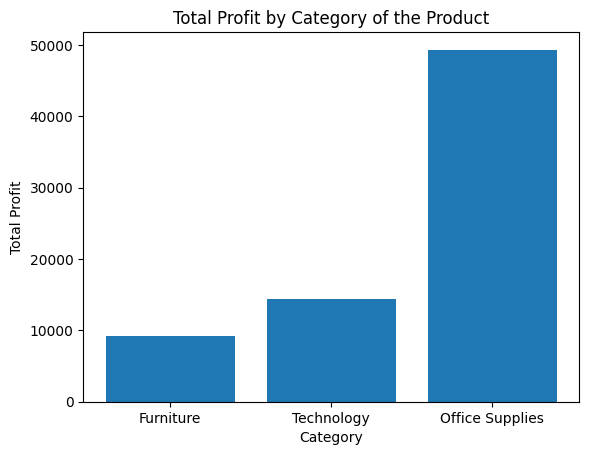

In [14]:
#Plotting a bar graph to know how much category contributes to profit.
import matplotlib
import matplotlib.pyplot as plt

categorical_profit = cleaned.groupby('Category')['Profit'].sum().sort_values()

fig, ax = plt.subplots()
ax.bar(categorical_profit.index, categorical_profit.values)

plt.title("Total Profit by Category of the Product")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.show()

### 3\.2\.2 Profit by State of Customer

"State of Customer" wise "Profit" generation tells us which state is generating most profit so that there is a further scope of investments as a new branch of superstore can be established at that state leading to more profit\. \(most customers will go to superstore of their state only \)

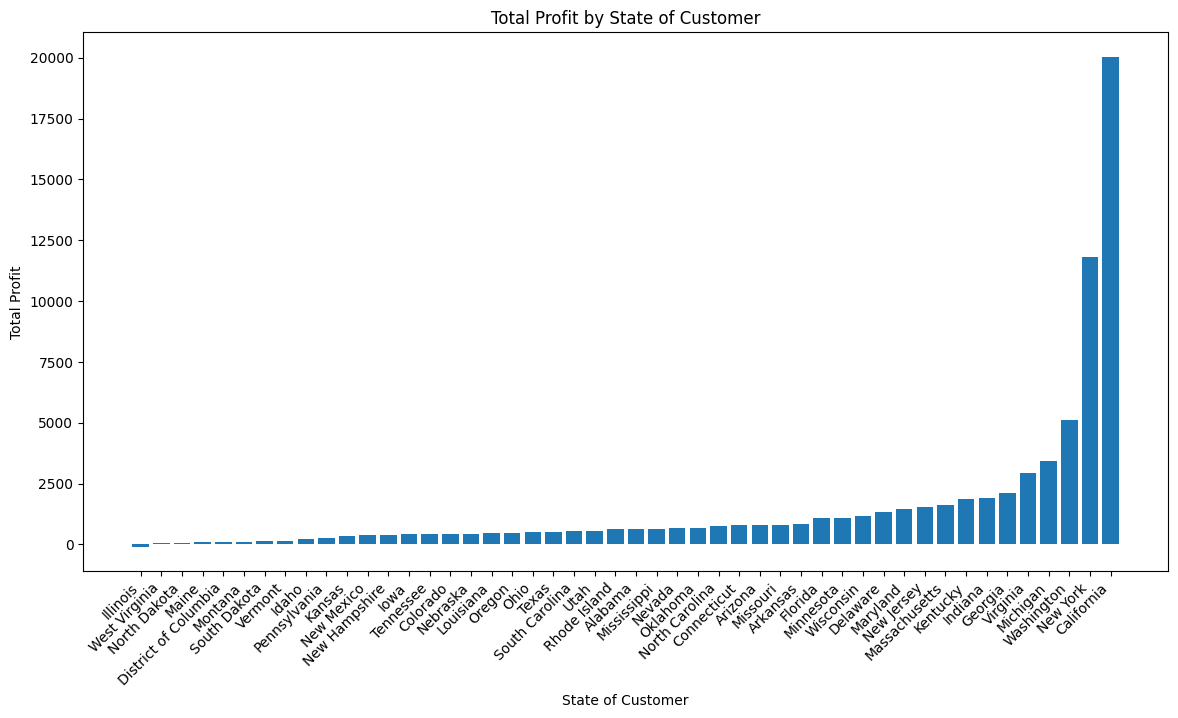

In [15]:
#Plotting a bar graph to understand Customer state wise profit 
profit_by_state = cleaned.groupby('State')['Profit'].sum().sort_values()

fig, ax = plt.subplots(figsize=(14, 7))
ax.bar(profit_by_state.index, profit_by_state.values)

plt.title("Total Profit by State of Customer")
plt.xlabel("State of Customer")
plt.ylabel("Total Profit")
plt.xticks(rotation=45, ha='right')

plt.show()

### 3\.2\.3 Sales by Region

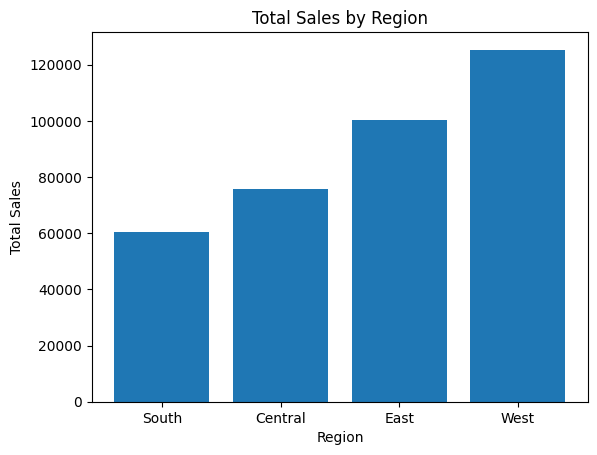

In [16]:
#Plotting a bar graph to know how much sales is generated by each region
sales_by_region = cleaned.groupby('Region')['Sales'].sum().sort_values()

fig, ax = plt.subplots()
ax.bar(sales_by_region.index, sales_by_region.values)

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

### 3\.2\.4 Order Count by Ship Mode

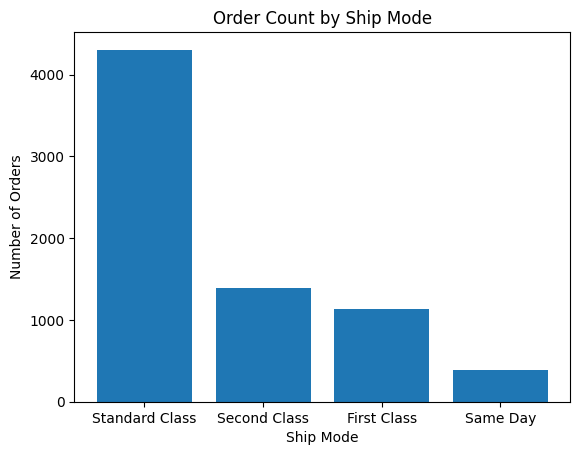

In [17]:
#Plotting a bar graph to know the number of orders by each shipping modes 
shipmode_counts = cleaned['Ship Mode'].value_counts()

fig, ax = plt.subplots()
ax.bar(shipmode_counts.index, shipmode_counts.values)

plt.title("Order Count by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Number of Orders")

plt.show()

### 3\.2\.5 Sales vs Profit Scatter Plot

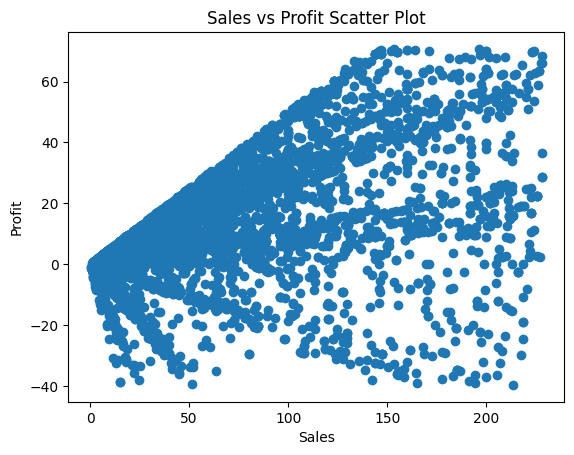

In [18]:
#Plotting a scatter plot to see the change in profit with sales
fig, ax = plt.subplots()
ax.scatter(cleaned['Sales'], cleaned['Profit'])
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.title('Sales vs Profit Scatter Plot')
plt.show()

### 3\.2\.6 Profit over Time 

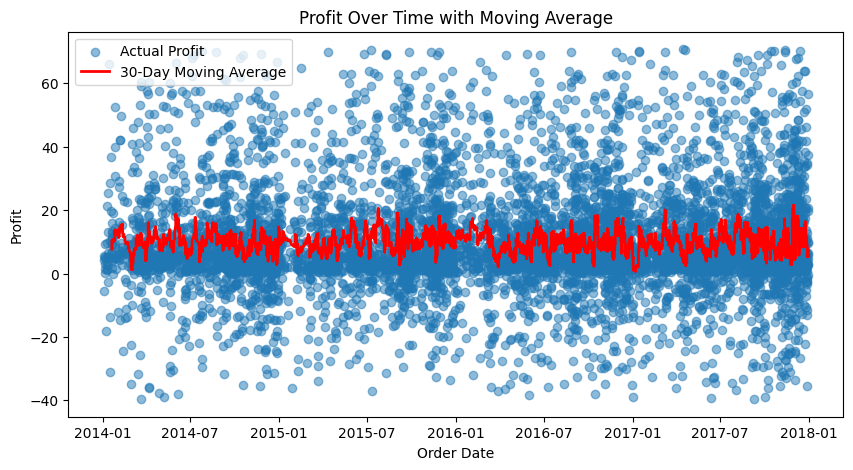

In [22]:
#'Order Date' was already converted to datetime while cleaning 

# Sorting by date to ensure proper rolling
cleaned = cleaned.sort_values('Order Date')

# Setting rolling window (assuming 30 days window)
cleaned['Profit_MA'] = cleaned['Profit'].rolling(window=30).mean()

# Plotting scatter plot and moving average line
fig, ax = plt.subplots(figsize=(10,5))
ax.scatter(cleaned['Order Date'], cleaned['Profit'], alpha=0.5, label='Actual Profit')
ax.plot(cleaned['Order Date'], cleaned['Profit_MA'], color='red', linewidth=2, label='30-Day Moving Average')

plt.xlabel('Order Date')
plt.ylabel('Profit')
plt.title('Profit Over Time with Moving Average')
plt.legend()
plt.show()


### 3\.2\.7 Scatter Matrix 

To understand important relationship between the most important continuous numerical data which causes impacts on profitability of superstore\.  

array([[<Axes: xlabel='Sales', ylabel='Sales'>,
        <Axes: xlabel='Profit', ylabel='Sales'>,
        <Axes: xlabel='Discount', ylabel='Sales'>,
        <Axes: xlabel='Quantity', ylabel='Sales'>],
       [<Axes: xlabel='Sales', ylabel='Profit'>,
        <Axes: xlabel='Profit', ylabel='Profit'>,
        <Axes: xlabel='Discount', ylabel='Profit'>,
        <Axes: xlabel='Quantity', ylabel='Profit'>],
       [<Axes: xlabel='Sales', ylabel='Discount'>,
        <Axes: xlabel='Profit', ylabel='Discount'>,
        <Axes: xlabel='Discount', ylabel='Discount'>,
        <Axes: xlabel='Quantity', ylabel='Discount'>],
       [<Axes: xlabel='Sales', ylabel='Quantity'>,
        <Axes: xlabel='Profit', ylabel='Quantity'>,
        <Axes: xlabel='Discount', ylabel='Quantity'>,
        <Axes: xlabel='Quantity', ylabel='Quantity'>]], dtype=object)

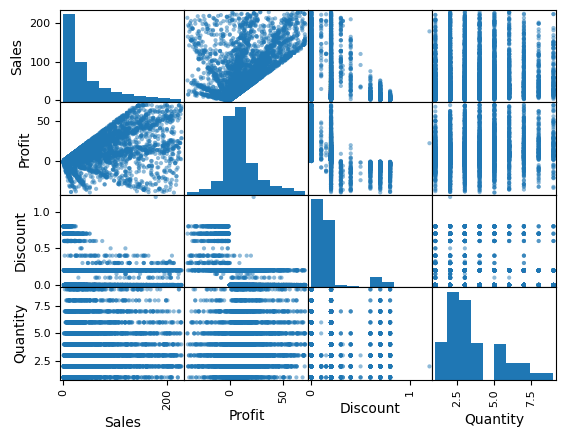

In [23]:
pd.plotting.scatter_matrix(cleaned.loc[:,['Sales', 'Profit', 'Discount', 'Quantity']])

### 3\.2\.8 Correlation Matrix

To understand the strength and direction of relationships between multiple variables, helping identify which variables affects positively  in generating profit and which affects negatively towards profitability\.

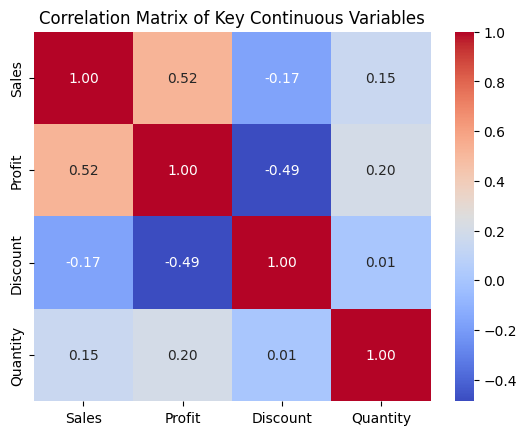

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.heatmap(cleaned[['Sales','Profit','Discount','Quantity']].corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Key Continuous Variables")
plt.show()

### 3\.2\.9 Covariance Matrix

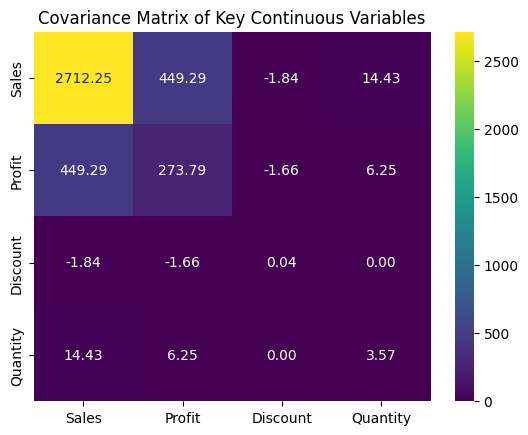

In [25]:
plt.figure()
sns.heatmap(cleaned[['Sales','Profit','Discount','Quantity']].cov(),
            annot=True, cmap="viridis", fmt=".2f")
plt.title("Covariance Matrix of Key Continuous Variables")
plt.show()

## 4\. Modelling Strategy

Based on the correlation matrix, Profit shows meaningful relationships with predictors like Sales, Discount, and Quantity, and low inter\-correlation among them supports using Multiple Linear Regression to quantify individual effects, statistical significance, and model accuracy\.

### 4\.1 Multiple Linear Regression

Using statsmodel \(Performing OLS\) and not scikit\-learn for performing Multiple linear regression as our main aim is to drive statistical inferences and explanations, not predictions\. 

In [26]:
#importing all necessary libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [27]:
#Preparing data for OLS Regression and selecting the variable which effect Profit
df_reg = cleaned[['Profit', 'Sales', 'Quantity', 'Discount', 'Category', 'Sub-Category', 'Region']]

In [28]:
# Using drop_first=True to avoid multicollinearity (Dummy Variable Trap)
df_reg = pd.get_dummies(df_reg, drop_first=True)

In [29]:
# Converting boolean columns to integers (0 or 1) to prevent ValueError in statsmodels
for col in df_reg.select_dtypes(include='bool').columns:
    df_reg[col] = df_reg[col].astype(int)

In [30]:
# Defining target (y) and features (X)
y = df_reg['Profit']
X = df_reg.drop('Profit', axis=1)

In [31]:
# Using scikit-learn for Train,Test and Split
# Splitting the supemarket data into 70% training and 30% testing
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3,random_state=42 )

#printing the length of total, training and test samples
print(f"Total samples: {len(X)}")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}\n")

Total samples: 7213
Training samples: 5049
Testing samples: 2164



In [32]:
# Adding constant/intercept to the training and test datasets (Statasmodel OLS)
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

### 4\.1\.1 Calculating metrics for Training Data

In [33]:
# first using only training data (Fitting the OLS Model)
reg = sm.OLS(y_train, X_train_sm)
results = reg.fit()
results.params

#Printing Model Summary indicating performance on training data 
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                 Profit   R-squared:                       0.625
Model:                            OLS   Adj. R-squared:                  0.623
Method:                 Least Squares   F-statistic:                     398.5
Date:                Tue, 18 Nov 2025   Prob (F-statistic):               0.00
Time:                        12:16:44   Log-Likelihood:                -18859.
No. Observations:                5049   AIC:                         3.776e+04
Df Residuals:                    5027   BIC:                         3.791e+04
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

The Multiple Linear Regression model explains 62\.5% of the variance in Profit \(R² = 0\.625\), with strong, statistically significant predictors such as Sales \(coef = 0\.208, p < 0\.001, t = 59\.36\) and Discount \(coef = –36\.52, p < 0\.001, t=\-42\.63\), but the very high condition number \(1\.68e\+18\) indicates severe multicollinearity, reducing the model's reliability\.

### 4\.1\.2 Calculating metrics for Test Data

In [34]:
# Making predictions using the already fitted model and the unseen X_test data
y_pred = results.predict(X_test_sm)

In [35]:
#Calculating metrics now for only test data 
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)


print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2 Score): {r2:.4f}")

Mean Squared Error (MSE): 119.60
Root Mean Squared Error (RMSE): 10.94
R-squared (R2 Score): 0.5627


On unseen data, the model’s performance drops to R² = 0\.5627 with an RMSE of 10\.94, showing that the model generalises only moderately well and struggles to accurately predict profit, likely due to linearity limitations and multicollinearity\.

### 4\.1\.3 Actual vs Predicted Profit Plot \(MLR Output\) 

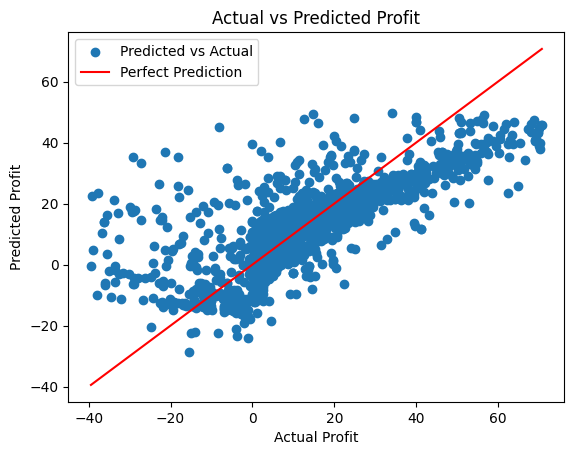

In [36]:
#using sklearn to plot the Actual vs Predicted Profit 
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

lm = LinearRegression()
lm.fit(X_train, y_train)

# Generating predictions
prediction = lm.predict(X_test)

# Plotting actual vs predicted Profit 
plt.figure()
plt.scatter(y_test, prediction, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', label='Perfect Prediction')

plt.xlabel('Actual Profit')
plt.ylabel('Predicted Profit')
plt.title('Actual vs Predicted Profit')
plt.legend()
plt.show()

### Why do we need a second model ?

The Multiple Linear regression Model provided us very useful insights with the directional influence of key predictors such as Sales, Quantity and Discount but its predictive accuracy remained limited with an R square of only 0\.56 on test set\. This performance indicates that there is still a remaining portion of variance in profit which is left unexplained\. MLR assumes linearity whereas our data is not\. Therefore, we need a model that is more flexible, non linear, captures complex interactions such as category and improves predictive accuracy as regional variations cannot be captured by straight lines, so using Random Forest Regression as it captures non linear, interaction heavy and hierarchical relationships automatically \(so is expected to increase predictive accuracy as well \)\.

### 4\.2 Random Forest Regressor

In [37]:
#importing all required libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn import preprocessing

In [38]:
# Resetting index to avoid misalignment
X = df_reg.drop('Profit', axis=1).reset_index(drop=True)
y = df_reg['Profit'].reset_index(drop=True)

In [39]:
# Splitting Data into 80% training and 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [40]:
# Scaling features
scaler = preprocessing.StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [41]:
# Training model
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train_scaled, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [42]:
# Predicting
y_pred_rf = rf.predict(X_test_scaled)

In [43]:
# Finding important Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae = mean_absolute_error(y_test, y_pred_rf)
r2_score = r2_score(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse)
print("Random Forest MAE:", mae)
print("Random Forest R2 score :",r2_score )

Random Forest RMSE: 7.064662327945798
Random Forest MAE: 3.18559378789747
Random Forest R2 score : 0.8188491785671289


The Random Forest produced RMSE = 7\.06, MAE = 3\.19, and R² = 0\.819 on the test set, significantly much better than MLR\. Numerically, Random Forest reduced RMSE from 10\.94 to 7\.06 \(35\.4% lower prediction error\) and increased R2 score by \+0\.256 \(from 0\.5627 to 0\.8189\), meaning Random Forest explains 82% of profit variance vs 56% for MLR\.

### 4\.2\.1 Feature Importance

In [44]:
# Feature importance (Attributes affecting Profit with their importance)
importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df.head(10))

                     Feature  Importance
0                      Sales    0.479841
2                   Discount    0.285799
17      Sub-Category_Storage    0.051868
3   Category_Office Supplies    0.038545
1                   Quantity    0.033494
15        Sub-Category_Paper    0.016437
7       Sub-Category_Binders    0.012388
18     Sub-Category_Supplies    0.010439
5    Sub-Category_Appliances    0.009447
6           Sub-Category_Art    0.008916


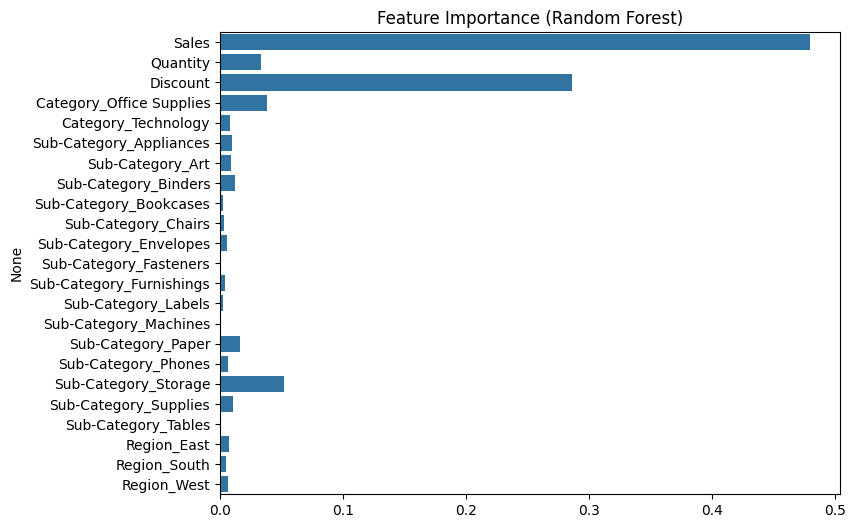

In [45]:
# Plotting Feature Importance
plt.figure(figsize=(8,6))
sns.barplot(x=importances, y=X.columns)
plt.title("Feature Importance (Random Forest)")
plt.show()

Random Forest confirmed that Profit depends on Sales = 48\.0% \(rounded off\), Discount = 28\.6%\(rounded off\), Sub\-Category: Storage = 5\.2%\(rounded off\), Category: Office Supplies = 3\.9%\(rounded off\), Quantity = 3\.3%\(rounded off\) and together these features dominate the model’s predictive power\. Profitability is primarily driven by Sales and Discount, Other variables contribute comparatively less, Non\-linear patterns strongly influence results\.